In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

# Cargar datos
print("Subir archivo AUTO.csv")
uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(filename)

# Limpieza de datos
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower', 'mpg'])

# Preparar modelos
modelos = {
    "Todas numéricas": ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin'],
    "Solo horsepower": ['horsepower'],
    "1/horsepower": ['horsepower'],
    "1/horsepower^2": ['horsepower'],
    "horsepower^2": ['horsepower']
}

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('mpg', axis=1),
    df['mpg'],
    test_size=0.2,
    random_state=42
)

# Función para validar supuestos CORREGIDA
def validar_supuestos(model, X, y):
    y_pred = model.predict(X)
    residuos = y - y_pred

    # Normalidad (Jarque-Bera) - CORRECCIÓN AQUÍ
    jb_test = jarque_bera(residuos)
    jb_pvalue = jb_test[1]
    normalidad = "Cumple" if jb_pvalue > 0.05 else "Violado"

    # Homocedasticidad (Breusch-Pagan)
    bp_test = het_breuschpagan(residuos, sm.add_constant(X))
    bp_pvalue = bp_test[1]
    homocedasticidad = "Cumple" if bp_pvalue > 0.05 else "Violado"

    # Independencia (Durbin-Watson)
    dw = durbin_watson(residuos)
    independencia = "Cumple" if 1.5 < dw < 2.5 else "Violado"

    return {
        'Normalidad': normalidad,
        'Homocedasticidad': homocedasticidad,
        'Durbin_Watson': round(dw, 2),
        'Independencia': independencia
    }

# Evaluar modelos
resultados = []
for nombre, vars in modelos.items():
    X_train_sel = X_train[vars].copy()
    X_test_sel = X_test[vars].copy()

    # Transformaciones
    if nombre == "1/horsepower":
        X_train_sel = 1 / X_train_sel
        X_test_sel = 1 / X_test_sel
    elif nombre == "1/horsepower^2":
        X_train_sel = 1 / (X_train_sel**2)
        X_test_sel = 1 / (X_test_sel**2)
    elif nombre == "horsepower^2":
        X_train_sel = X_train_sel**2
        X_test_sel = X_test_sel**2

    # Entrenar modelo
    model = LinearRegression()
    model.fit(X_train_sel, y_train)

    # Métricas
    y_pred = model.predict(X_test_sel)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Validar supuestos
    supuestos = validar_supuestos(model, X_train_sel, y_train)

    resultados.append({
        'Modelo': nombre,
        'MSE': round(mse, 4),
        'R2': round(r2, 4),
        **supuestos
    })

# Mostrar resultados
resultados_df = pd.DataFrame(resultados)
print("\nResultados de Modelos:")
display(resultados_df.sort_values('MSE'))

Subir archivo AUTO.csv


Saving AUTO.csv to AUTO (1).csv

Resultados de Modelos:


,Modelo,MSE,R2,Normalidad,Homocedasticidad,Durbin_Watson,Independencia
0,Todas numéricas,10.7109,0.7902,Violado,Violado,2.03,Cumple
2,1/horsepower,20.5286,0.5978,Violado,Violado,2.14,Cumple
1,Solo horsepower,22.1532,0.5660,Violado,Violado,2.13,Cumple
3,1/horsepower^2,26.1195,0.4883,Violado,Violado,2.17,Cumple
4,horsepower^2,27.0826,0.4694,Violado,Cumple,2.16,Cumple


Saving AUTO.csv to AUTO (2).csv

Modelo de IMG_5845:
Ecuación estimada: y = 39.94 + -0.16x
Ecuación en imagen: y = 34.43 - 0.15x

Durbin-Watson: 0.9195
Interpretación: Autocorrelación positiva

Modelo Cuadrático (IMG_5850):
Ecuación: mpg = 56.90 + -0.47hp + 0.00hp²

Correlación con MPG (solo variables numéricas):
weight         -0.832244
displacement   -0.805127
horsepower     -0.778427
cylinders      -0.777618
acceleration    0.423329
origin          0.565209
year            0.580541
mpg             1.000000
Name: mpg, dtype: float64


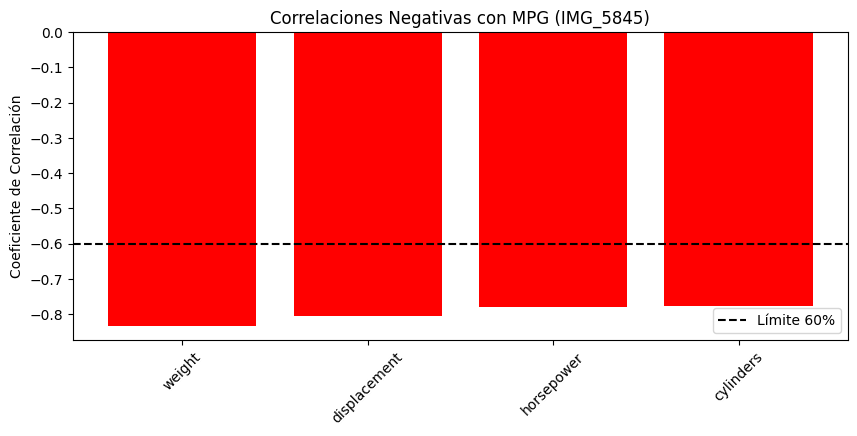

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson

# Cargar datos
from google.colab import files
uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(filename)

# Limpieza de datos
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower', 'mpg'])

# Modelo de IMG_5845: y = 34.43 - 0.15x
X_img = df[['horsepower']]
y_img = df['mpg']

model_img = LinearRegression()
model_img.fit(X_img, y_img)

print("\nModelo de IMG_5845:")
print(f"Ecuación estimada: y = {model_img.intercept_:.2f} + {model_img.coef_[0]:.2f}x")
print(f"Ecuación: y = 34.43 - 0.15x")

# Durbin-Watson para residuos
residuos_img = y_img - model_img.predict(X_img)
dw_img = durbin_watson(residuos_img)
print(f"\nDurbin-Watson: {dw_img:.4f}")
print("Interpretación:",
      "Autocorrelación positiva" if dw_img < 1.5 else
      "Autocorrelación negativa" if dw_img > 2.5 else
      "Sin autocorrelación significativa")

# Modelo cuadrático de IMG_5850: mpg = β₀ + β₁x + β₂x²
X_quad = df[['horsepower']].copy()
X_quad['horsepower_sq'] = X_quad['horsepower']**2
y_quad = df['mpg']

model_quad = LinearRegression()
model_quad.fit(X_quad, y_quad)

print("\nModelo Cuadrático (IMG_5850):")
print(f"Ecuación: mpg = {model_quad.intercept_:.2f} + {model_quad.coef_[0]:.2f}hp + {model_quad.coef_[1]:.2f}hp²")

# Gráfico de correlaciones negativas (IMG_5845) - CORRECCIÓN: Solo columnas numéricas
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mpg_corr = corr_matrix['mpg'].sort_values()

print("\nCorrelación con MPG (solo variables numéricas):")
print(mpg_corr)

# Gráfico
neg_corr = mpg_corr[mpg_corr < 0]
plt.figure(figsize=(10, 4))
plt.bar(neg_corr.index, neg_corr.values, color='red')
plt.axhline(y=-0.6, color='black', linestyle='--', label='Límite 60%')
plt.title('Correlaciones Negativas con MPG (IMG_5845)')
plt.ylabel('Coeficiente de Correlación')
plt.xticks(rotation=45)
plt.legend()
plt.show()